# Feedforward Network and Parity Learning

A feedforward network trained on a parity task (output 1 when an even number of input units are active). Evaluates SSE and accuracy over many forward-pass trials on new random patterns.

## Code

if the # of input units turned on is even then the
output is 1, otherwise the output is zero.

In [38]:
# LIBRARIES
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# PARAMETERS
lr = 1
n_input = 8
n_hidden = 3
n_output = 1
n_pattern = 8

In [40]:
# PATTERNS SET UP
row = 8
col = 8
np.random.seed(42)
patterns = (np.random.rand(n_input, n_pattern) > 0.5).astype(int)
print(patterns)

[[0 1 1 1 0 0 0 1]
 [1 1 0 1 1 0 0 0]
 [0 1 0 0 1 0 0 0]
 [0 1 0 1 1 0 1 0]
 [0 1 1 1 0 0 1 0]
 [0 0 0 1 0 1 0 1]
 [1 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 1 0]]


In [41]:
# DESIRED OUTPUT FOR EACH PATTERN
cnt_ones = np.sum(patterns, axis=0)
desired_outputs = (cnt_ones % 2 == 0).astype(int).reshape(1, n_pattern)
print(desired_outputs)

[[1 0 0 1 1 1 1 0]]


In [42]:
# MATRICES FOR WEIGHT
w_fg = (np.random.rand(n_hidden, n_input) - 0.5)
w_gh = (np.random.rand(n_output, n_hidden) - 0.5)

In [43]:
# ACTIVATION FUNCTION
def activation_fn(x):
  return 1 / (1 + np.exp(-x))

def d_activation_fn(x):
  f = activation_fn(x)
  return f * (1 - f)

Epoch 10: SSE = 1.4391
Epoch 20: SSE = 0.7704
Epoch 30: SSE = 0.3369
Epoch 40: SSE = 0.1706
Epoch 50: SSE = 0.1036
Epoch 60: SSE = 0.0713
Epoch 70: SSE = 0.0531
Epoch 80: SSE = 0.0418
Epoch 90: SSE = 0.0341
Epoch 100: SSE = 0.0287
Epoch 110: SSE = 0.0246
Epoch 120: SSE = 0.0215
Epoch 130: SSE = 0.0191
Epoch 140: SSE = 0.0171
Epoch 150: SSE = 0.0154
Epoch 160: SSE = 0.0141
Epoch 170: SSE = 0.0129
Epoch 180: SSE = 0.0119
Epoch 190: SSE = 0.0111
Epoch 200: SSE = 0.0103
Converged at epoch 205.


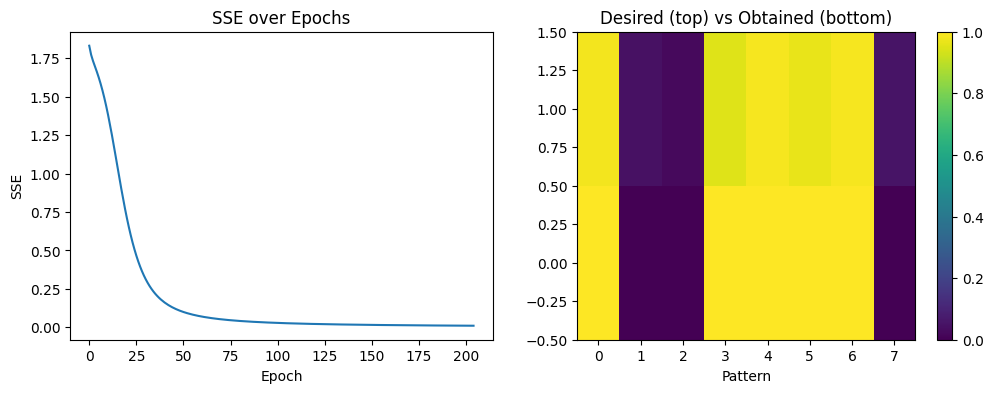

In [44]:
# ITERATION LOOP
sse_history = []
convergence = False

for epoch in range(1,1001):
  for i in range(n_pattern):
    pattern = patterns[:, [i]]
    desired_output = desired_outputs[:, [i]]

    input_to_hidden = w_fg @ pattern # a
    hidden_activation = activation_fn(input_to_hidden) # b
    input_to_output = w_gh @ hidden_activation # c
    output_activation = activation_fn(input_to_output) # d
    output_error = desired_output - output_activation # e
    # f
    dw_fg = lr * (np.diag(d_activation_fn(input_to_hidden).flatten()) @ w_gh.T @ (d_activation_fn(input_to_output) * output_error)) @ pattern.T
    dw_gh = lr * (d_activation_fn(input_to_output) * output_error) @ hidden_activation.T
    # g
    w_fg += dw_fg
    w_gh += dw_gh
  # h
  all_input_to_hidden = w_fg @ patterns
  all_hidden_activation = activation_fn(all_input_to_hidden)
  all_input_to_output = w_gh @ all_hidden_activation
  all_output_activation = activation_fn(all_input_to_output)
  all_output_error = desired_outputs - all_output_activation
  sse = np.trace(all_output_error @ all_output_error.T)
  sse_history.append(sse)
  # i
  if epoch % 10 == 0:
    print(f"Epoch {epoch}: SSE = {sse:.4f}")

  if sse < 0.01:
    convergence = True
    print(f"Converged at epoch {epoch}.")

    # plots
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(sse_history)
    plt.title("SSE over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("SSE")

    plt.subplot(1, 2, 2)
    combined_outputs = np.vstack((desired_outputs, all_output_activation))
    plt.imshow(combined_outputs, aspect='auto', origin='lower') #, cmap='gray')
    plt.colorbar()
    plt.xlabel("Pattern")
    plt.title("Desired (top) vs Obtained (bottom)")
    plt.show()
    break

if not convergence:
  print('Warning: Model did not converge within 1000 epochs.')

Average Generalization SSE: 3.1892
Average Generalization Accuracy: 53.23%


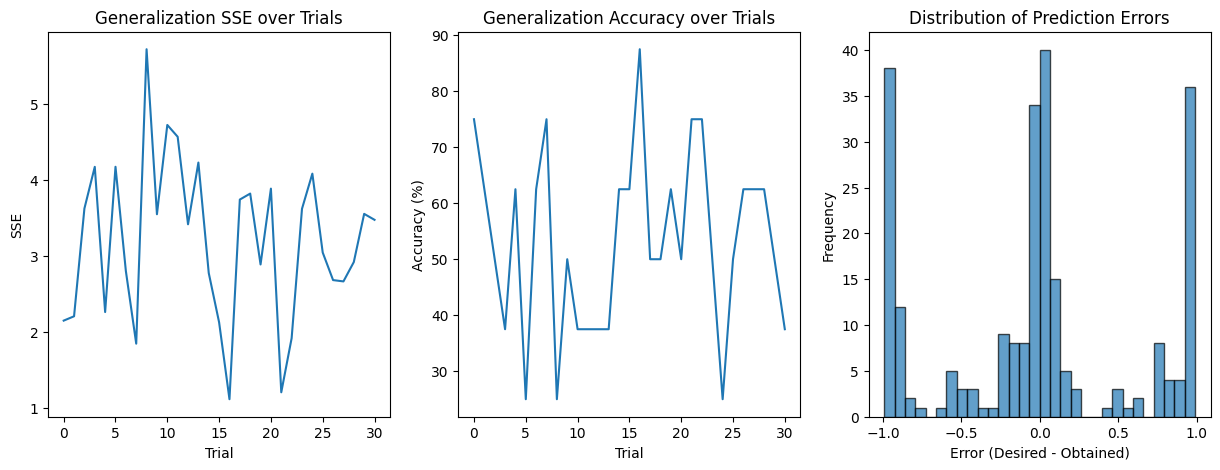

In [45]:
# GENERALIZATION
generalized_sse_history = []
accuracy_history = []
all_errors_dist = []

for i in range(1, 32): # 100 trials
  test_patterns = (np.random.rand(n_input, n_pattern) > 0.5).astype(int)
  test_ones = np.sum(test_patterns, axis=0)
  test_desired = (test_ones % 2 == 0).astype(int).reshape(1, n_pattern)

  # a - e
  test_input_to_hidden = w_fg @ test_patterns
  test_hidden_activation = activation_fn(test_input_to_hidden)
  test_input_to_output = w_gh @ test_hidden_activation
  test_output_activation = activation_fn(test_input_to_output)
  test_output_error = test_desired - test_output_activation
  test_sse = np.trace(test_output_error @ test_output_error.T)

  generalized_sse_history.append(test_sse)

  predictions = (test_output_activation > 0.5).astype(int)
  accuracy = np.mean(predictions == test_desired) * 100

  accuracy_history.append(accuracy)

  raw_errors = (test_desired - test_output_activation).flatten()
  all_errors_dist.extend(raw_errors)

print(f"Average Generalization SSE: {np.mean(generalized_sse_history):.4f}")
print(f"Average Generalization Accuracy: {np.mean(accuracy_history):.2f}%")

# plot
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(generalized_sse_history)
plt.title("Generalization SSE over Trials")
plt.xlabel("Trial")
plt.ylabel("SSE")

plt.subplot(1, 3, 2)
plt.plot(accuracy_history)
plt.title("Generalization Accuracy over Trials")
plt.xlabel("Trial")
plt.ylabel("Accuracy (%)")

plt.subplot(1, 3, 3)
plt.hist(all_errors_dist, bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (Desired - Obtained)")
plt.ylabel("Frequency")
plt.show()

After running 100 new forward pass only trials of new random patterns (which there is a possibility that there is the exact same, but very unlikely), we have the average SSE and accuracy, which is printed out in the cell above. We also have the distribution of them, and the distribution of the total errors.

The accuracy (~53.23%) is very close to 50%, which is the chance for a binary parity task. That is, even if you randomly pick a number, you will get a similar result. The relatively big SSE, compared to the SSE threshold, proves that this network failed to generalize, but rather memorized the pattern. The network was trained with very little patterns out of the 256 existing ones, it overfitted the data.

The small number of the hidden units also made it hard to find a general rule for all possible inputs. The error distribution shows that the trained model sometimes gives the exact opposite of the correct answers for the new patterns generated for generalization testing.